[2026-08-04 14:48:28] [info     ] 计算因子，区间：2024-10-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-04 14:52:53] [info     ] 读取因子库，区间：2024-10-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-04 14:52:53] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-04 14:52:54] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-04 14:52:54] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-04 14:52:54] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-10-08 至 2024-12-31
[2026-08-04 14:52:54] [info     ] ========== 数据检查 ==========
[2026-08-04 14:52:54] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg

时段,IC
2024-09-24~2024-10-08,-0.0187

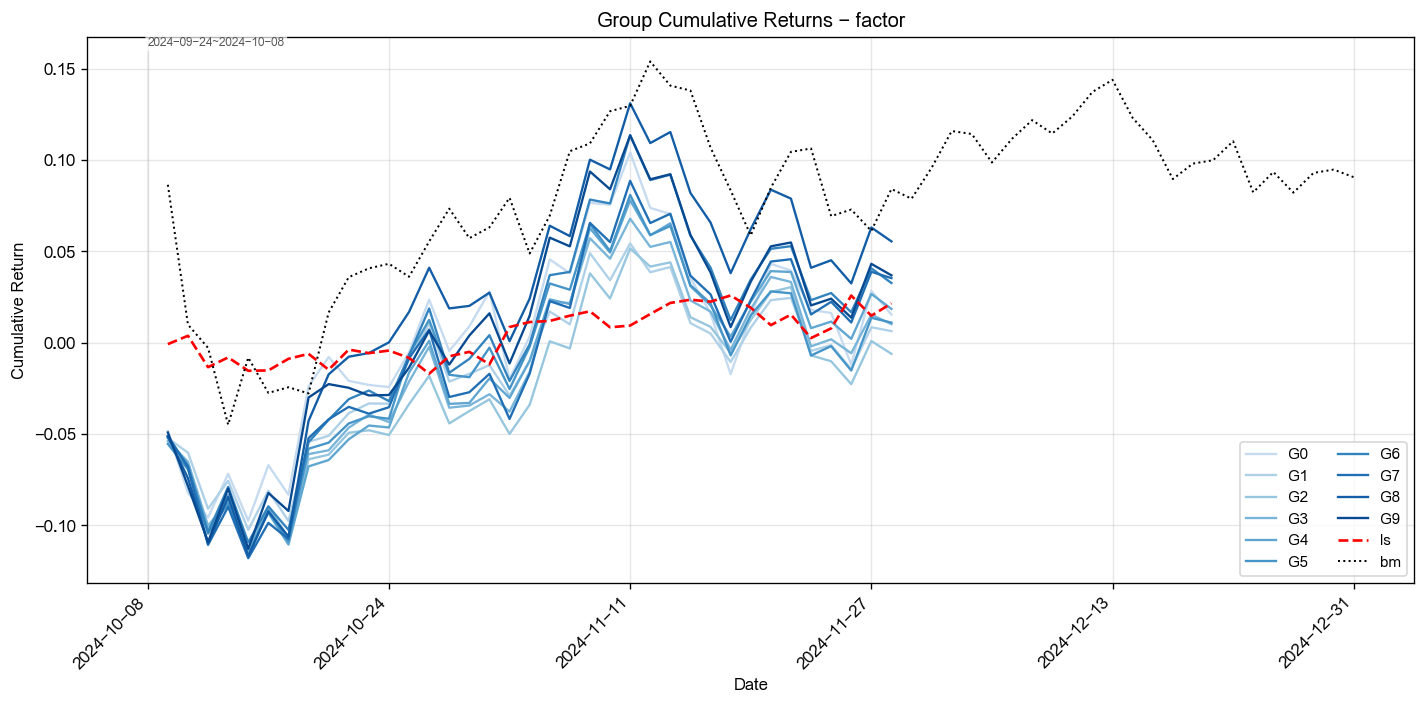
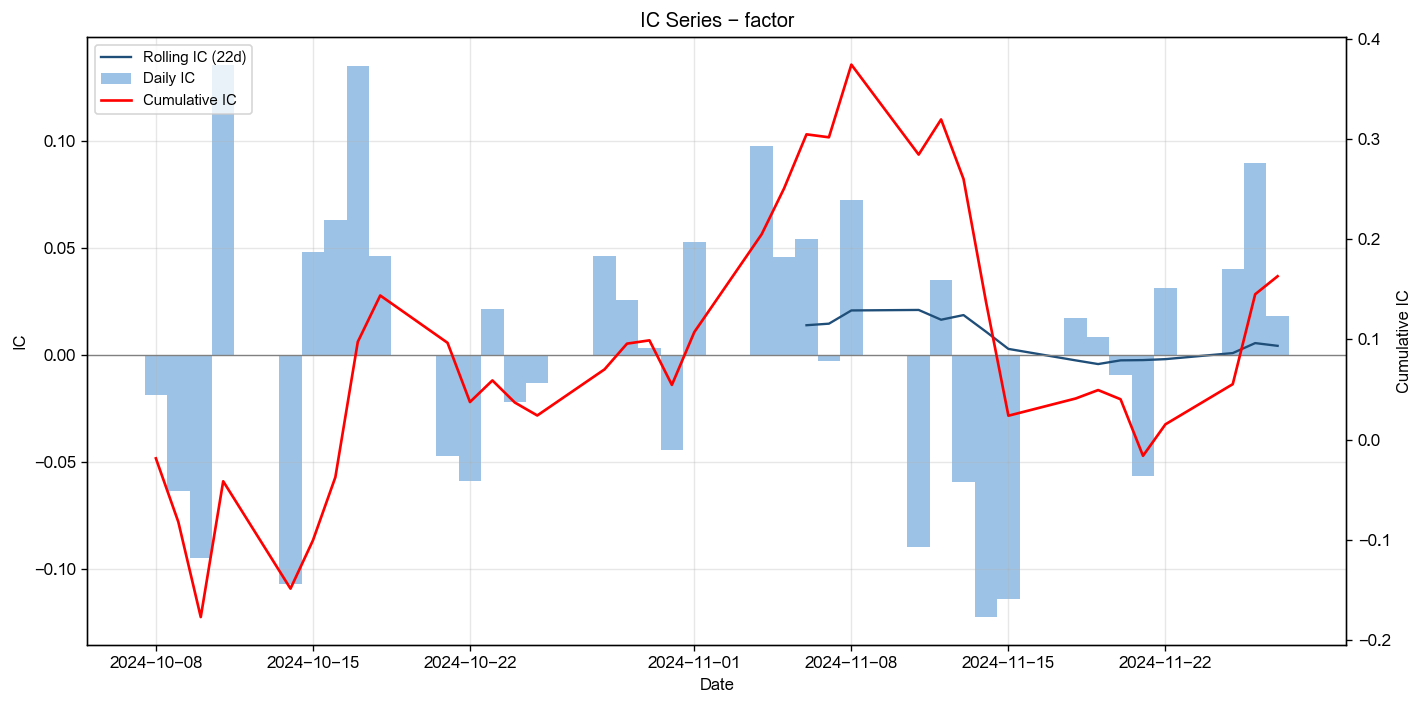
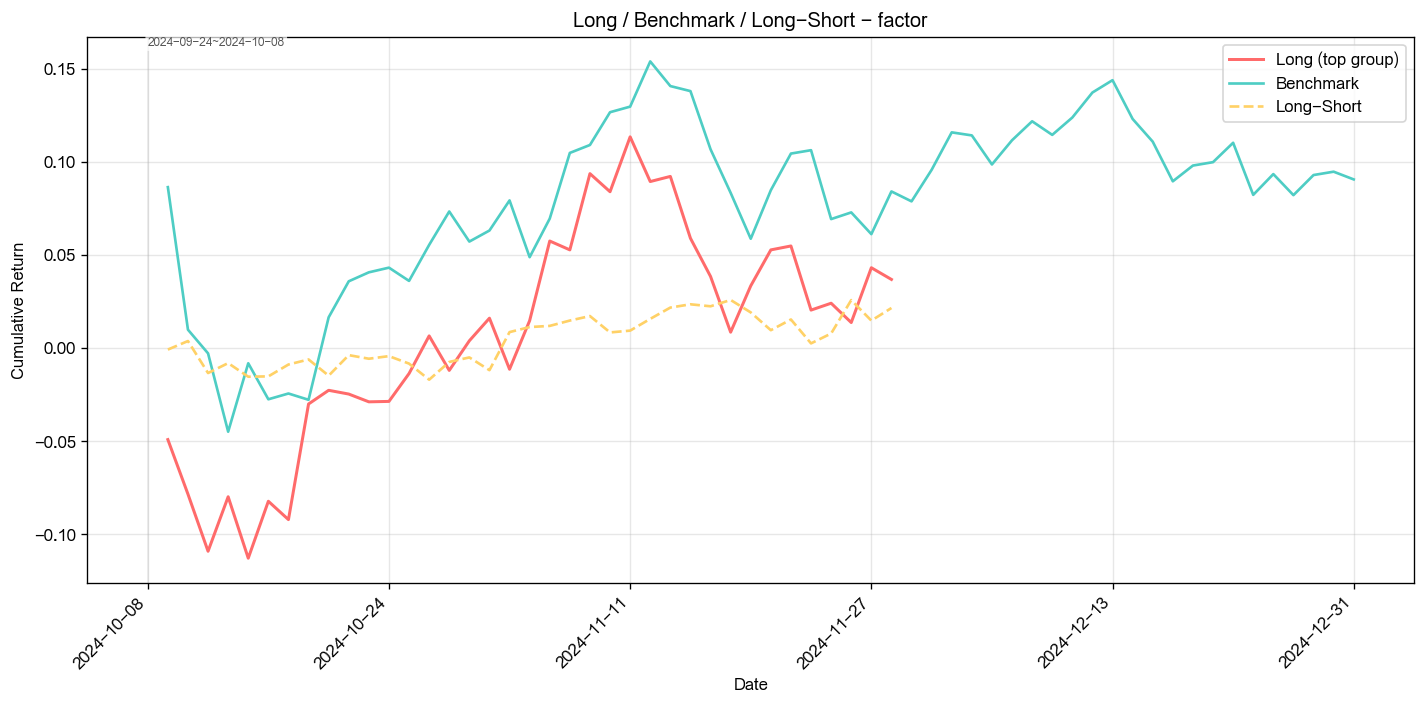
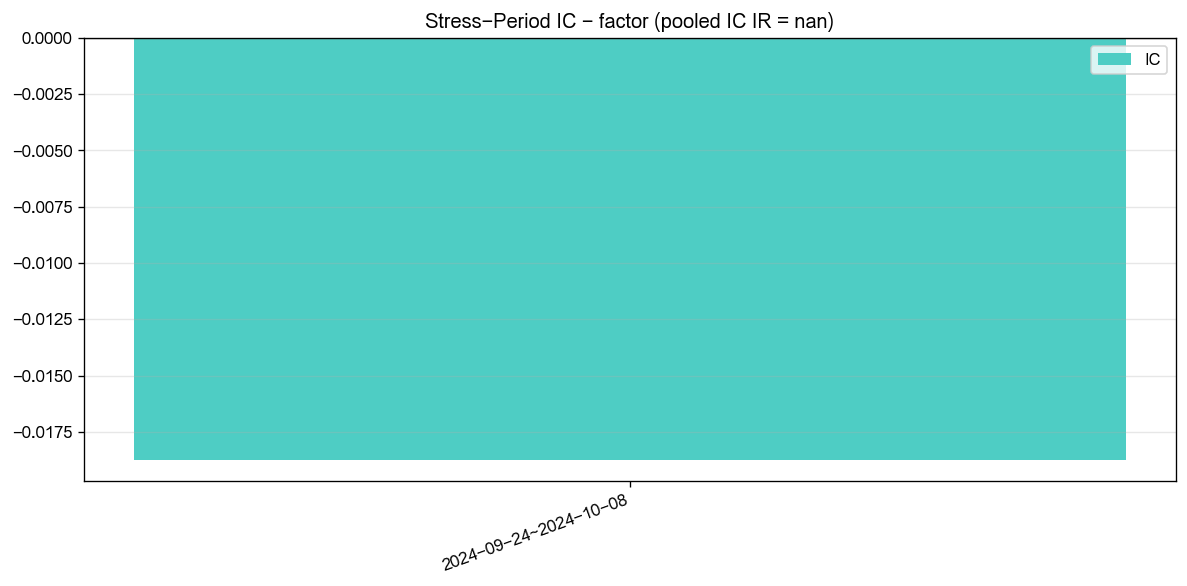
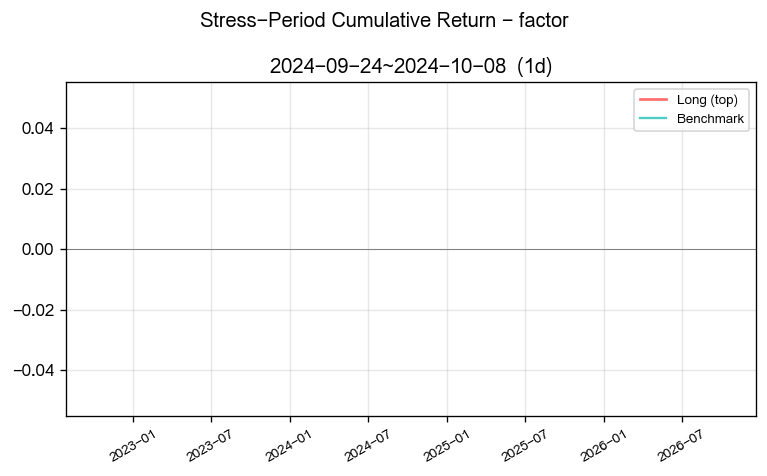

[2026-08-04 14:53:00] [info     ] ========== 因子池回归 ==========
[2026-08-04 14:53:00] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1100 rows=76237 start_date=2024-10-08
[2026-08-04 14:53:00] [info     ] 获取收益率数据, 耗时: 0.8003 秒
[2026-08-04 14:53:01] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.0483 秒
[2026-08-04 14:53:01] [info     ] 统计 回归结果, 耗时: 0.0144 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,kdj_d_9_3_3,8344719.5874,0.0834,0.0000,1.0000
2,bias_20,4663561.9616,0.0466,0.0000,1.0000
3,kdj_k_9_3_3,4643190.5307,0.0464,0.0000,1.0000
4,momentum_5,4318412.2761,0.0432,0.0000,1.0000
5,net_active_buy_amount_main,3765421.2195,0.0377,0.0000,1.0000
6,macd_diff_12_26_9,2688324.8099,0.0269,0.0000,1.0000
7,cci_14,2492276.3158,0.0249,0.0000,1.0000
8,macd_dea_12_26_9,2091279.1607,0.0209,0.0000,1.0000
9,daily_return,1673254.6338,0.0167,0.0000,1.0000
10,netflow_amount_main,1663780.6754,0.0166,0.0000,1.0000

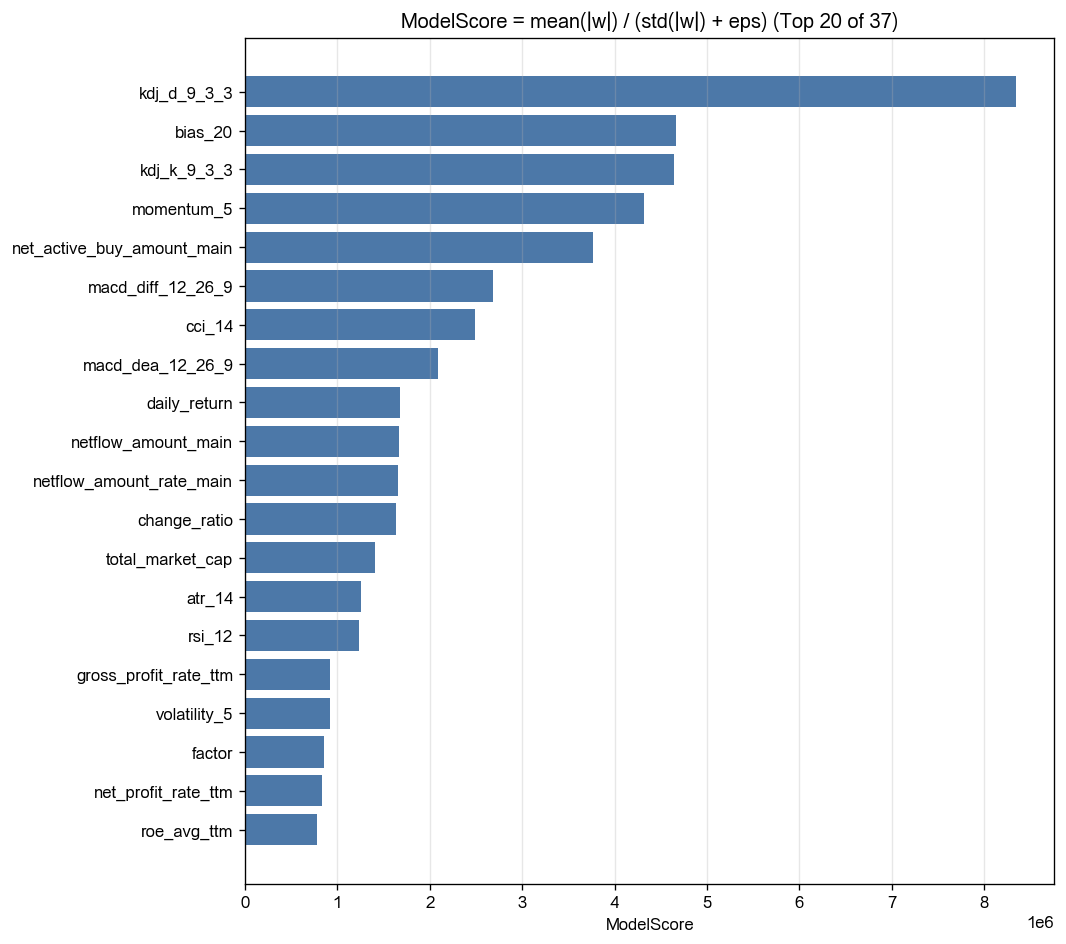
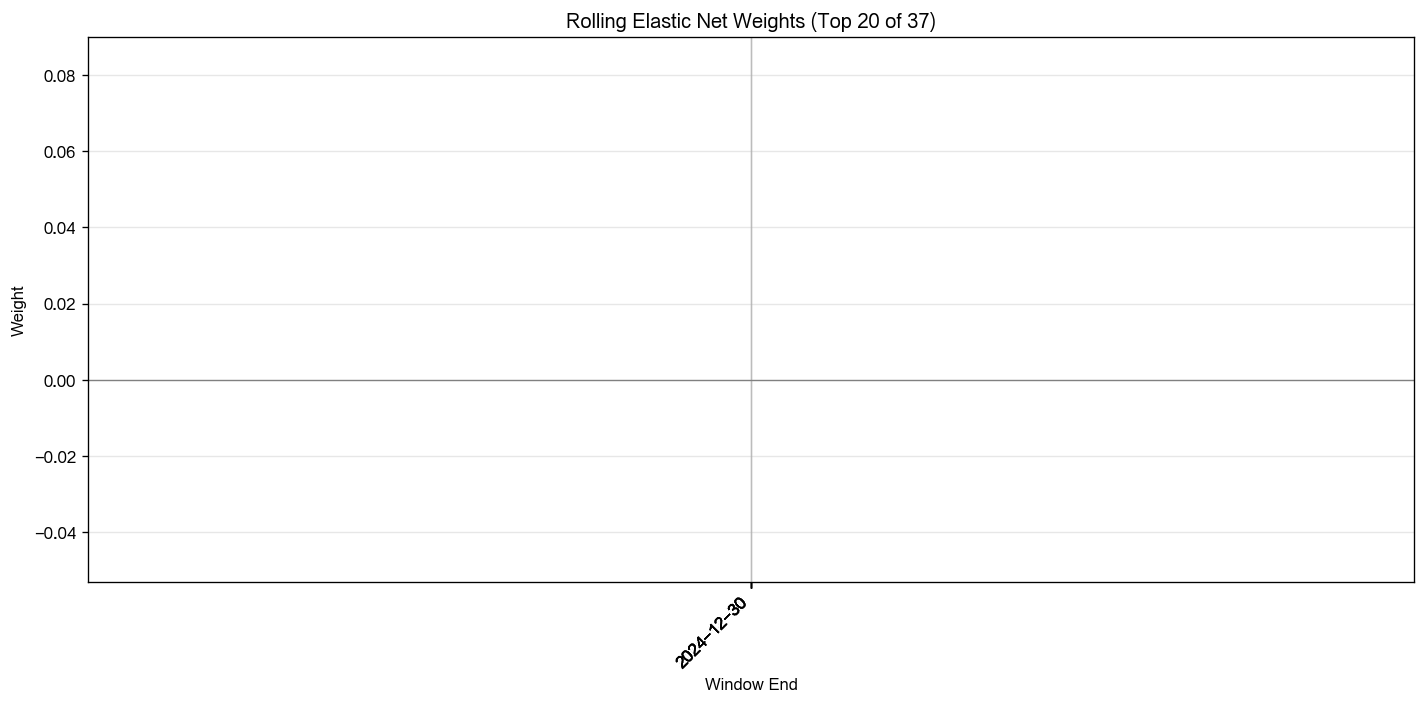
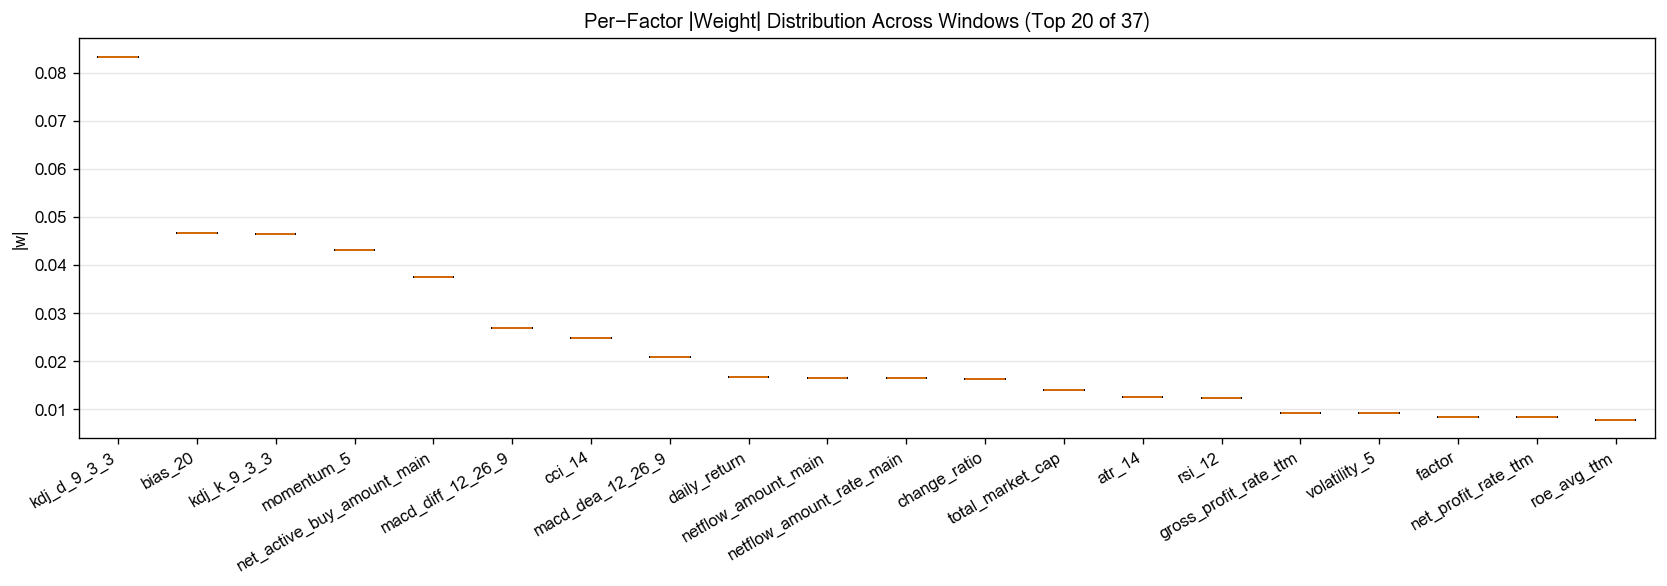
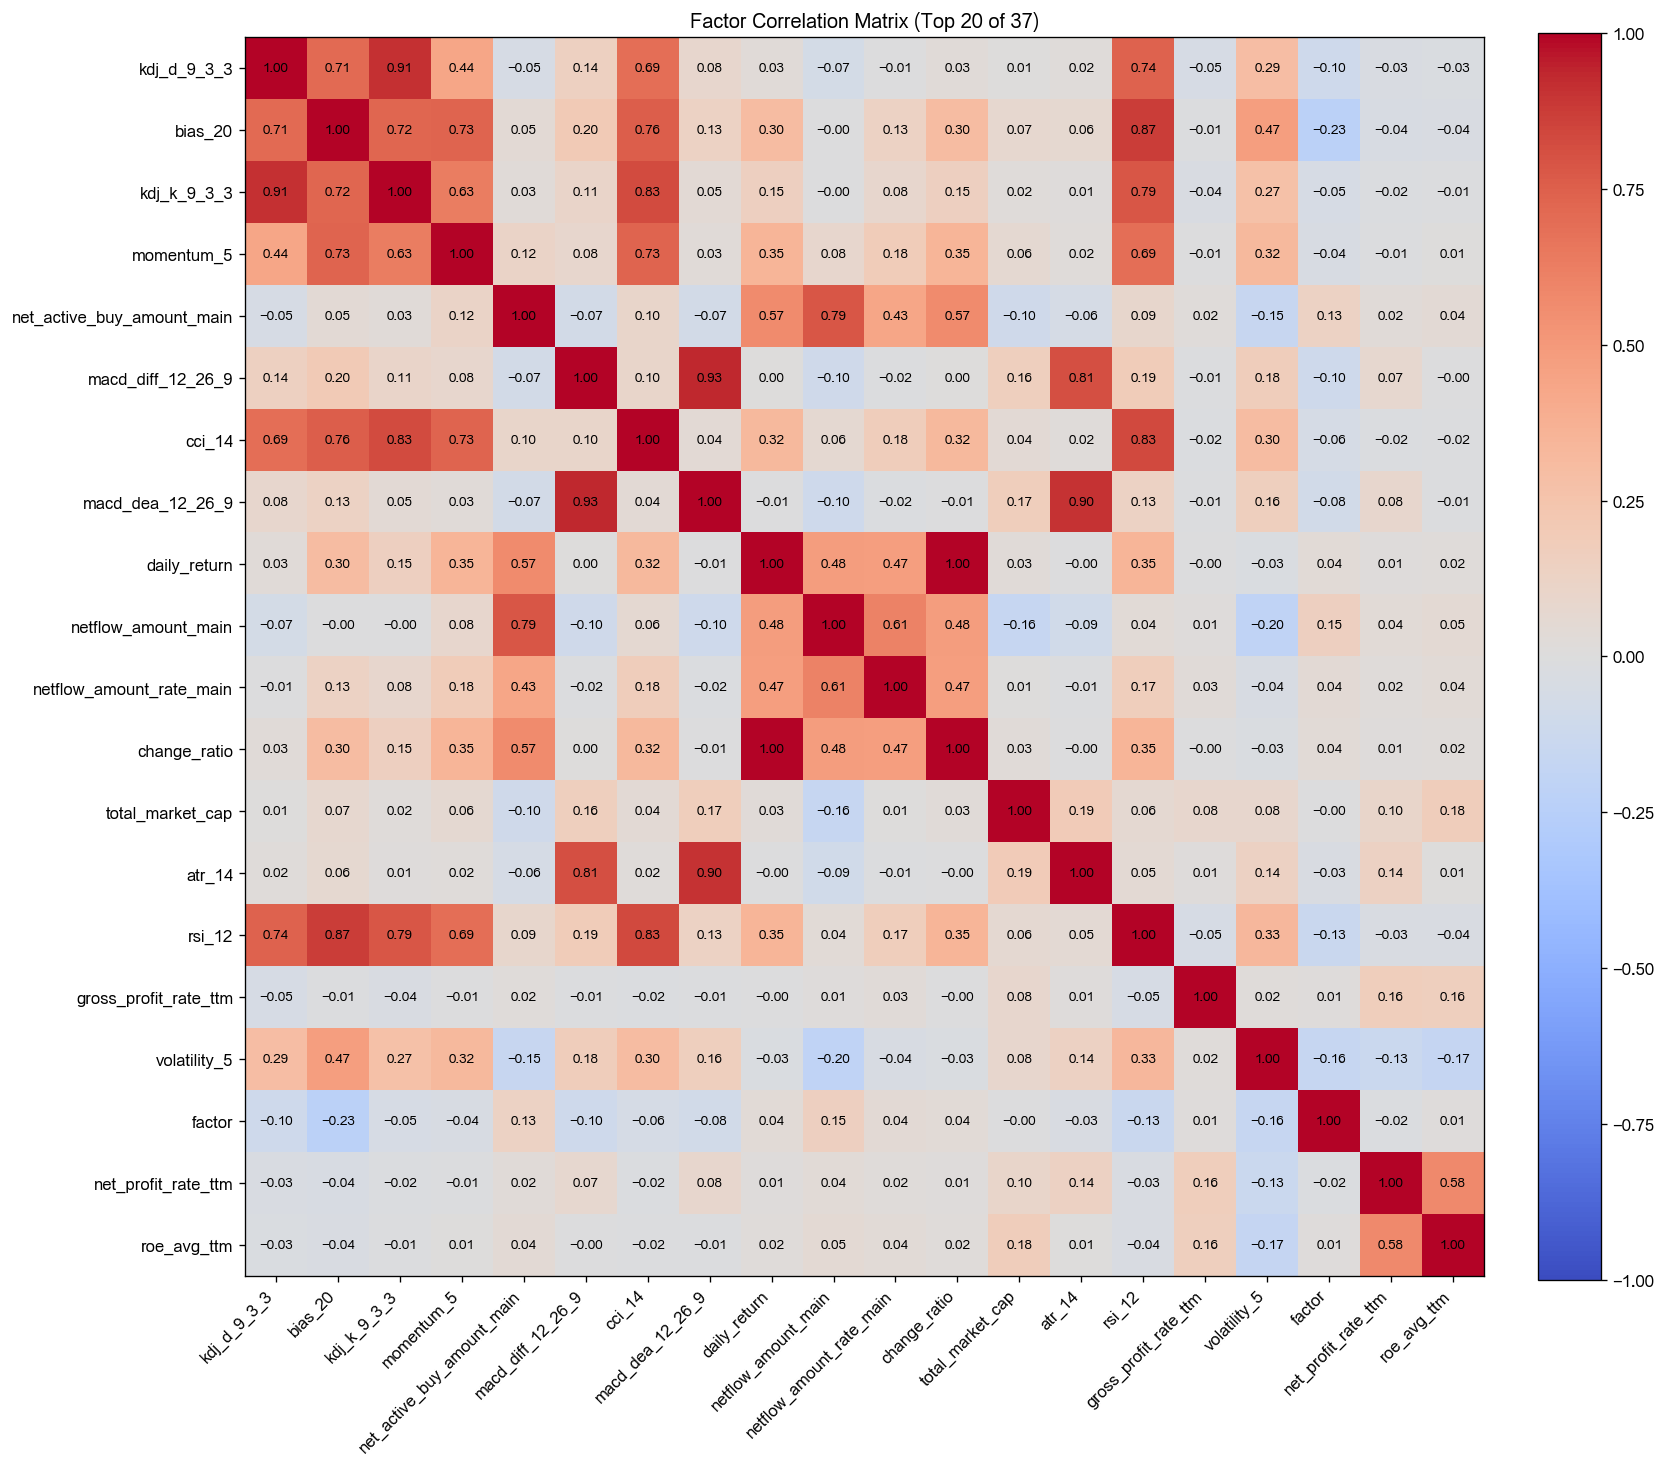

[2026-08-04 14:53:03] [warning  ] 返回的Outputs实例(size=8518581) 大于 64K, 将不会被缓存
[2026-08-04 14:53:03] [info     ] bigalpha_eval.v4 运行完成 [9.100s].


In [61]:
#  风浪越大🐟越贵 因子1-2
def main(datasources, start_date, end_date):
    """
    因子构建主函数

    评测时平台会自动替换 datasources / start_date / end_date 三个入参并调用本函数

    参数:
        datasources (dict): 数据源表名映射 {逻辑名: 物理表名}。一个因子可同时用到多张表，
                            通过逻辑名取出该阶段实际的物理表名，平台会在公榜/私榜自动切换。
                            当前可用逻辑名:
                                "bar1m"     -> 分钟 K 线表
                                "financial" -> 财务数据表
                                "instrument_1000" -> 中证1000券池
        start_date (str): 开始时间
        end_date (str):   结束时间

    返回:
        pd.DataFrame: 因子数据，须包含三列 ['date', 'instrument', 'factor']，且不含 inf
    """
    import pandas as pd
    import dai
    import numpy as np


    # 获取前几天数据
    LOOKBACK_DAYS = 30
    query_start_date = pd.to_datetime(start_date) - pd.Timedelta(days=LOOKBACK_DAYS)


    # 获取动态券池
    stk_pool = dai.query(f"""SELECT * FROM bigalpha_2026_instruments""",filters={'date': [query_start_date, end_date]}).df()
    stk_pool = stk_pool.drop(columns='name')
    stk_pool['SH'] = True

    # 获取交易日期
    trade_day = stk_pool['date'].sort_values().unique().tolist()

    # 获取股票列表
    stock_list = stk_pool['instrument'].tolist()

    # 获取分钟数据
    factor_value = pd.DataFrame(index=trade_day)
    # 获取1m分钟数据
    df = dai.query(f"select date,instrument,high,low,close,open,amount,volume from {datasources['bar1m']} where instrument in {tuple(stock_list)}",filters={'date':[query_start_date,end_date]}).df()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['day'] = df['date'].dt.normalize()
    df.sort_values(['instrument','date'],inplace=True)
    df.set_index('date', inplace=True)

    # 删除尾盘集合竞价时间
    drop_times=[pd.to_datetime("14:58:00").time(),pd.to_datetime("14:59:00").time(),pd.to_datetime("15:00:00").time()]
    time_series = pd.Series(df.index.time,index=df.index)
    mask = ~time_series.isin(drop_times)
    df = df[mask]

    for name_day,stock_df in df.groupby(['instrument','day']):
        # print(name_day)
        stock_name = name_day[0]
        day = name_day[1]
        # print(stock_df)
        # 成交量激增时刻
        volume_diff = stock_df['volume'].diff()
        volume_diff_mean = volume_diff.mean()
        volume_diff_std = volume_diff.std()
        threshold = volume_diff_mean + 1 * volume_diff_std
        volume_diff_main = volume_diff[volume_diff > threshold]

        # 耀眼5分钟 成交量激增带来的价格波动率
        vol_mean = stock_df.close.pct_change().rolling(5).std().shift(-4).loc[volume_diff_main.index].mean()
        factor_value.loc[day,stock_name] = vol_mean

    # 周期更短 factor_value
    ret_std_mean = factor_value.rolling(3).mean()

    # 动态券池过滤
    stk_pool = dai.query(f"""SELECT * FROM bigalpha_2026_instruments""",filters={'date': [query_start_date, end_date]}).df()
    stk_pool = stk_pool.sort_values('date')
    stk_pool = stk_pool.drop(columns='name')
    stk_pool['SH'] = True
    stk_pool = stk_pool.pivot(index = 'date',columns = 'instrument',values='SH')
    ret_std_mean = ret_std_mean[stk_pool]


    # 波动率因子
    ret_std_dis = ret_std_mean.sub(ret_std_mean.mean(axis=1),axis=0).abs()
    ret_std_dis = -ret_std_dis

    # 因子值输出
    factor1_value = ret_std_dis.stack().to_frame().reset_index()
    factor1_value.columns = ['date','instrument','factor']

    # 因子2 因子1的均值
    factor2 = factor1_value.pivot(index='date',columns='instrument',values='factor')
    factor2_value = factor2.rolling(10).mean()
    factor2_value = factor2_value.stack().to_frame('factor').reset_index()
    factor2_value = factor2_value.dropna(how='any',axis=0)

    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    factor2_value = pd.merge(factor2_value, stk_pool, how='inner', on=['date', 'instrument'])

    return factor2_value


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # 本地自测时自行构造数据源映射（评测时由平台注入，逻辑名固定为 "bar1m"/"financial"）
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m',
                    'financial':'bigalpha_2026_financial'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    # 计算因子
    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取平台因子库用于回归评估，您可以换成自己的因子库
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    # 评估系统：
    # process_pools=False 表示不对因子库再做预处理（bigalpha_2026_factorlib 已处理过）
    # show=True 表示画出评估图表
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
